# File loading

In [2]:
import pandas as pd

df = pd.read_csv("fixation/18sat_fixfinal.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)

(463564, 29)
['RECORDING_SESSION_LABEL', 'TRIAL_INDEX', 'CURRENT_FIX_X', 'CURRENT_FIX_Y', 'CURRENT_FIX_PUPIL', 'CURRENT_FIX_DURATION', 'CURRENT_FIX_INTEREST_AREA_ID', 'CURRENT_FIX_INTEREST_AREA_LABEL', 'CURRENT_FIX_INTEREST_AREA_PIXEL_AREA', 'CURRENT_FIX_INTEREST_AREA_RUN_ID', 'CURRENT_FIX_INTEREST_AREA_DWELL_TIME', 'PREVIOUS_SAC_DIRECTION', 'PREVIOUS_SAC_ANGLE', 'PREVIOUS_SAC_AMPLITUDE', 'PREVIOUS_SAC_AVG_VELOCITY', 'PREVIOUS_SAC_CONTAINS_BLINK', 'PREVIOUS_SAC_BLINK_DURATION', 'Session_Name_', 'Trial_Index_', 'Trial_Recycled_', 'total_page', 'type', 'book_name', 'book', 'page', 'RT', 'answer', 'correct_answer', 'page_name']
  RECORDING_SESSION_LABEL  TRIAL_INDEX  CURRENT_FIX_X  CURRENT_FIX_Y  \
0                  msd001            1           59.8          125.4   
1                  msd001            1          348.7          182.0   
2                  msd001            1          630.5          400.3   
3                  msd001            1          492.0          400.2   
4      

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 463564 entries, 0 to 463563
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RECORDING_SESSION_LABEL               463564 non-null  str    
 1   TRIAL_INDEX                           463564 non-null  int64  
 2   CURRENT_FIX_X                         463564 non-null  float64
 3   CURRENT_FIX_Y                         463564 non-null  float64
 4   CURRENT_FIX_PUPIL                     463564 non-null  float64
 5   CURRENT_FIX_DURATION                  463564 non-null  int64  
 6   CURRENT_FIX_INTEREST_AREA_ID          251087 non-null  float64
 7   CURRENT_FIX_INTEREST_AREA_LABEL       251087 non-null  str    
 8   CURRENT_FIX_INTEREST_AREA_PIXEL_AREA  251087 non-null  float64
 9   CURRENT_FIX_INTEREST_AREA_RUN_ID      251087 non-null  float64
 10  CURRENT_FIX_INTEREST_AREA_DWELL_TIME  251087 non-null  float64
 11  PREVIOUS_SA

# Pre-processing

In [4]:
## Distinguishing between reading the passages or answering the questions

reading = df[df["type"] == "reading"].copy()
questions = df[df["type"] == "question"].copy()

In [5]:
## Get comprehension score per passage
# One row per question rather than one row per fixation
question_trials = (
    questions[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "page",
            "answer",
            "correct_answer"
        ]
    ]
    .drop_duplicates()
)

# Scored comprehension questions only
comprehension_questions = question_trials[
    question_trials["correct_answer"] != -99
].copy()

comprehension_questions["correct"] = (
    comprehension_questions["answer"]
    == comprehension_questions["correct_answer"]
).astype(int)

passage_comprehension = (
    comprehension_questions
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_correct=("correct", "sum"),
        n_questions=("correct", "count"),
        comprehension_score=("correct", "mean")
    )
    .reset_index()
)

In [6]:
print(passage_comprehension.head())

  RECORDING_SESSION_LABEL  book_name  n_correct  n_questions  \
0                  msd001    dickens          3            5   
1                  msd001    flytrap          4            5   
2                  msd001     genome          4            5   
3                  msd001  northpole          4            5   
4                  msd002    dickens          3            5   

   comprehension_score  
0                  0.6  
1                  0.8  
2                  0.8  
3                  0.8  
4                  0.6  


In [7]:
## Try to get the same median score as paper to classify as high/low comprehension level

median_comprehension = passage_comprehension["comprehension_score"].median()

print("Median comprehension:", median_comprehension)


Median comprehension: 0.6


In [8]:
passage_comprehension["comprehension_level"] = (
    passage_comprehension["comprehension_score"]
    .apply(lambda x: "High" if x >= median_comprehension else "Low")
)

print(passage_comprehension.head(10))

  RECORDING_SESSION_LABEL  book_name  n_correct  n_questions  \
0                  msd001    dickens          3            5   
1                  msd001    flytrap          4            5   
2                  msd001     genome          4            5   
3                  msd001  northpole          4            5   
4                  msd002    dickens          3            5   
5                  msd002    flytrap          0            5   
6                  msd002     genome          3            5   
7                  msd002  northpole          3            5   
8                  msd003    dickens          3            5   
9                  msd003    flytrap          4            5   

   comprehension_score comprehension_level  
0                  0.6                High  
1                  0.8                High  
2                  0.8                High  
3                  0.8                High  
4                  0.6                High  
5                  0.0   

In [9]:
passage_comprehension.shape

(380, 6)

In [10]:
## Calculate overall_comprehension

overall_comprehension = (
    passage_comprehension
    .groupby("RECORDING_SESSION_LABEL")
    .agg(
        n_correct=("n_correct", "sum"),
        n_questions=("n_questions", "sum")
    )
    .reset_index()
)

overall_comprehension["comprehension_score"] = (
    overall_comprehension["n_correct"]
    / overall_comprehension["n_questions"]
)

print(overall_comprehension.head())

  RECORDING_SESSION_LABEL  n_correct  n_questions  comprehension_score
0                  msd001         15           20                 0.75
1                  msd002          9           20                 0.45
2                  msd003         13           20                 0.65
3                  msd004         12           20                 0.60
4                  msd005         15           20                 0.75


In [11]:
overall_median = overall_comprehension["comprehension_score"].median()

print("Overall comprehension median:", overall_median)

Overall comprehension median: 0.55


In [12]:
overall_comprehension["comprehension_level"] = (
   overall_comprehension["comprehension_score"]
    .apply(lambda x: "High" if x >= overall_median else "Low")
)

print(overall_comprehension.head(10))


  RECORDING_SESSION_LABEL  n_correct  n_questions  comprehension_score  \
0                  msd001         15           20                 0.75   
1                  msd002          9           20                 0.45   
2                  msd003         13           20                 0.65   
3                  msd004         12           20                 0.60   
4                  msd005         15           20                 0.75   
5                  msd007         17           20                 0.85   
6                  msd008         11           20                 0.55   
7                  msd009         12           20                 0.60   
8                  msd010          9           20                 0.45   
9                  msd011         10           20                 0.50   

  comprehension_level  
0                High  
1                 Low  
2                High  
3                High  
4                High  
5                High  
6                

In [13]:
overall_comprehension.shape

(95, 5)

# Statistical analysis

## Eye-tracking measures

Start with the measures used in the original SB-SAT paper:

* **Mean fixation duration**
  * Time spent during individual fixations.
  * Longer fixation durations can indicate greater processing demands during reading (e.g., Just & Carpenter, 1980).
  * SB-SAT found longer mean fixation durations for low compared with high passage comprehension.

* **Reading rate**
  * Overall reading speed, expressed as words per minute (WPM).
  * SB-SAT found higher reading rates for participants with higher passage comprehension.

* **Mean saccade amplitude**
  * How far the eye moves between consecutive fixations.
  * SB-SAT found larger mean saccade amplitudes for higher passage comprehension.

* **Mean pupil size**
  * Pupil dilation can be related to cognitive load (e.g., Krejtz et al., 2018).
  * However, pupil size is influenced by other factors such as luminance.
  * SB-SAT did not find significant differences in pupil size between comprehension groups.

Additional interpretable reading measures:

* **Regression rate / count**
  * Number or proportion of backward eye movements during reading.
  * Regressions can indicate rereading and increased processing demands.
  * However, regressions should not automatically be interpreted as poor comprehension:
    readers may regress to integrate information, verify something, or strategically reread
    (e.g., Booth & Weger, 2013; Raney et al., 2014).
  * Regression was suggested as a possible feature for future work in the SB-SAT paper.

* **Fixation count**
  * Number of fixations made while reading a passage.
  * Can provide an indication of the amount of visual/cognitive processing devoted to the text.
  * Should be interpreted together with reading time and fixation duration, since these measures are related.

## General interpretation

Fixation duration, fixation count, and regressions can provide indicators of
processing demands during text comprehension.

These measures should not be interpreted deterministically. For example,
more regressions do not necessarily mean poorer comprehension; they may also
reflect strategic rereading or active integration of information.

The aim is therefore to examine whether these eye-tracking measures are
**associated with passage comprehension**, rather than treating any individual
eye-tracking behaviour as evidence of poor comprehension.

## Unit of analysis: participant × passage

One row represents one participant reading one passage.

This choice aligns the eye-tracking predictors with the level at which passage
comprehension was measured in SB-SAT. Passage comprehension is a score for a
specific participant on a specific passage, so eye-tracking behaviour is aggregated
over that same participant–passage combination.

For example:

Participant 1 + Dickens  
→ eye-tracking behaviour while reading Dickens  
→ comprehension score for Dickens

Participant 1 + Flytrap  
→ eye-tracking behaviour while reading Flytrap  
→ comprehension score for Flytrap

Reasons for using participant × passage as the unit of analysis:

1. **Avoids a mismatch between local eye movements and a global outcome.**
   In the original paper, 21-fixation windows inherited the passage-level
   comprehension label. The authors acknowledge that this assumes that local
   reading behaviour reflects comprehension at the level of the whole passage.

2. **Avoids pseudo-replication.**
   Individual fixations are not independent comprehension observations.
   Comprehension was measured once for each participant–passage combination.

3. **Provides interpretable passage-level predictors.**
   Eye-tracking measures such as mean fixation duration, fixation count,
   saccade amplitude, and regression rate can be summarised for the complete
   reading of a passage and directly related to that passage's comprehension score.

4. **Fits the repeated-measures structure of the data.**
   Each participant reads multiple passages, so observations from the same
   participant are related. This can be accounted for using a mixed-effects model.

In [14]:
eye_features = (
    reading
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        mean_fix_duration=("CURRENT_FIX_DURATION", "mean"),
        median_fix_duration=("CURRENT_FIX_DURATION", "median"),
        n_fixations=("CURRENT_FIX_DURATION", "count"),
        mean_saccade_amplitude=("PREVIOUS_SAC_AMPLITUDE", "mean"),
        mean_pupil_size=("CURRENT_FIX_PUPIL", "mean")
    )
    .reset_index()
)

print(eye_features.head(10))
print(eye_features.shape)

  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   
5                  msd002    flytrap         225.617680                199.0   
6                  msd002     genome         258.632266                218.0   
7                  msd002  northpole         250.137691                210.0   
8                  msd003    dickens         267.781377                243.0   
9                  msd003    flytrap         250.510135                212.5   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  
0          510                5.353921      1610.600000  
1  

In [15]:
analysis_df = eye_features.merge(
    passage_comprehension,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(analysis_df.head(10))
print(analysis_df.shape)

  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   
5                  msd002    flytrap         225.617680                199.0   
6                  msd002     genome         258.632266                218.0   
7                  msd002  northpole         250.137691                210.0   
8                  msd003    dickens         267.781377                243.0   
9                  msd003    flytrap         250.510135                212.5   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  n_correct  \
0          510                5.353921      1610.

In [16]:
## Check whether it indeed is correct, we expect 95 unique participants and 4 passages. For each passage, we expect 95 counts

print("Participants:",
      analysis_df["RECORDING_SESSION_LABEL"].nunique())

print("Passages:",
      analysis_df["book_name"].nunique())

print(analysis_df["book_name"].value_counts())

Participants: 95
Passages: 4
book_name
dickens      95
flytrap      95
genome       95
northpole    95
Name: count, dtype: int64


In [17]:
## Check whether each particpant has 4 passages

print(
    analysis_df
    .groupby("RECORDING_SESSION_LABEL")
    .size()
    .value_counts()
)

4    95
Name: count, dtype: int64


In [18]:
# checking missing values
print(analysis_df.isna().sum())

RECORDING_SESSION_LABEL    0
book_name                  0
mean_fix_duration          0
median_fix_duration        0
n_fixations                0
mean_saccade_amplitude     0
mean_pupil_size            0
n_correct                  0
n_questions                0
comprehension_score        0
comprehension_level        0
dtype: int64


In [19]:
# Looking at distributions

print(
    analysis_df[
        [
            "mean_fix_duration",
            "median_fix_duration",
            "n_fixations",
            "mean_saccade_amplitude",
            "mean_pupil_size",
            "comprehension_score"
        ]
    ].describe()
)

       mean_fix_duration  median_fix_duration  n_fixations  \
count         380.000000           380.000000   380.000000   
mean          209.715434           195.009211   692.189474   
std            30.576494            27.239712   193.298983   
min           125.158621           100.000000    56.000000   
25%           189.839568           178.000000   556.750000   
50%           206.388384           191.000000   693.500000   
75%           227.528074           211.250000   831.500000   
max           308.080851           273.000000  1188.000000   

       mean_saccade_amplitude  mean_pupil_size  comprehension_score  
count              380.000000       380.000000           380.000000  
mean                 4.251564      1577.103424             0.562632  
std                  0.834489       443.616260             0.238671  
min                  2.556715       607.095745             0.000000  
25%                  3.652277      1290.251836             0.400000  
50%                  

The mean being higher than the median suggests that fixation durations are somewhat right-skewed, which is very common for fixation-duration data: some unusually long fixations pull the mean upward.

Other variables look quite similar

Only jump out is fixation count, one has only 56 fixations for a whole passage

In [20]:
#check which passage is low

print(
    analysis_df[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations",
            "mean_fix_duration",
            "comprehension_score"
        ]
    ]
    .sort_values("n_fixations")
    .head(10)
)

    RECORDING_SESSION_LABEL book_name  n_fixations  mean_fix_duration  \
40                   msd012   dickens           56         136.517857   
328                  msd094   dickens          120         224.341667   
192                  msd056   dickens          145         125.158621   
234                  msd068    genome          220         223.386364   
42                   msd012    genome          267         155.734082   
145                  msd043   flytrap          276         204.855072   
76                   msd024   dickens          292         164.702055   
22                   msd007    genome          319         212.661442   
41                   msd012   flytrap          329         175.158055   
332                  msd095   dickens          340         162.152941   

     comprehension_score  
40                   0.6  
328                  0.2  
192                  0.8  
234                  0.2  
42                   0.4  
145                  0.0  
76     

In [21]:
#Upper end

print(
    analysis_df[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations",
            "mean_fix_duration",
            "comprehension_score"
        ]
    ]
    .sort_values("n_fixations", ascending=False)
    .head(10)
)

    RECORDING_SESSION_LABEL  book_name  n_fixations  mean_fix_duration  \
129                  msd038    flytrap         1188         180.967172   
355                  msd100  northpole         1158         202.584629   
259                  msd074  northpole         1145         192.647162   
229                  msd066    flytrap         1143         190.517935   
249                  msd072    flytrap         1131         212.012378   
256                  msd074    dickens         1102         193.768603   
251                  msd072  northpole         1096         211.625000   
257                  msd074    flytrap         1085         204.438710   
69                   msd022    flytrap         1084         217.961255   
258                  msd074     genome         1082         200.540665   

     comprehension_score  
129                  0.8  
355                  0.8  
259                  0.6  
229                  0.2  
249                  0.6  
256                  0.

## Data quality checks

Before statistical analysis, inspect whether each participant–passage
combination contains sufficient eye-tracking data.

Checks:
* Number of recorded pages compared with the expected number of pages.
* Number of fixations per participant × passage.
* Potentially compare summed fixation duration with recorded reading time.
* Do not automatically remove extreme observations; first determine whether
  they represent plausible reading behaviour or incomplete eye-tracking data.

In [22]:
quality_check = (
    reading
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_pages=("page", "nunique"),
        expected_pages=("total_page", "max"),
        n_fixations=("CURRENT_FIX_DURATION", "count")
    )
    .reset_index()
)

quality_check["complete_passage"] = (
    quality_check["n_pages"] == quality_check["expected_pages"]
)

print(
    quality_check[~quality_check["complete_passage"]]
    .sort_values("n_fixations")
)

    RECORDING_SESSION_LABEL  book_name  n_pages  expected_pages  n_fixations  \
328                  msd094    dickens        1               5          120   
145                  msd043    flytrap        2               6          276   
76                   msd024    dickens        3               5          292   
22                   msd007     genome        4               6          319   
11                   msd003  northpole        3               5          373   
120                  msd036    dickens        4               5          423   
246                  msd071     genome        5               6          447   
71                   msd022  northpole        3               5          486   
78                   msd024     genome        5               6          521   
108                  msd033    dickens        4               5          571   
68                   msd022    dickens        4               5          635   
318                  msd091     genome  

In [23]:
analysis_df = analysis_df.merge(
    quality_check[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_pages",
            "expected_pages",
            "complete_passage"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

In [24]:
print(analysis_df["complete_passage"].value_counts())

complete_passage
True     357
False     23
Name: count, dtype: int64


In [25]:
analysis_complete = (
    analysis_df[
        analysis_df["complete_passage"]
    ]
    .copy()
)

print(analysis_complete.shape)

(357, 14)


### Data quality

Passage-level eye-tracking features should represent the complete passage.

1. Remove participant–passage observations for which not all passage pages
   contain recorded fixation data.
2. Inspect unusually sparse fixation recordings among the remaining complete
   passages.
3. Do not exclude observations based solely on being statistically extreme;
   determine whether the pattern reflects plausible reading behaviour or
   incomplete/poor-quality eye-tracking data.

In [26]:
#Fixation count per passage

print(
    analysis_complete
    .groupby("book_name")["n_fixations"]
    .describe()
)

           count        mean         std    min     25%    50%    75%     max
book_name                                                                    
dickens     89.0  629.516854  182.609625   56.0  523.00  625.0  740.0  1102.0
flytrap     89.0  774.359551  189.434280  329.0  644.00  784.0  915.0  1188.0
genome      87.0  727.977011  167.750575  220.0  612.50  741.0  850.5  1041.0
northpole   92.0  651.304348  173.392633  371.0  515.75  619.0  765.0  1158.0


In [27]:
# Looking at distributions

print(
    analysis_df[
        [
            "mean_fix_duration",
            "median_fix_duration",
            "n_fixations",
            "mean_saccade_amplitude",
            "mean_pupil_size",
            "comprehension_score"
        ]
    ].describe()
)

       mean_fix_duration  median_fix_duration  n_fixations  \
count         380.000000           380.000000   380.000000   
mean          209.715434           195.009211   692.189474   
std            30.576494            27.239712   193.298983   
min           125.158621           100.000000    56.000000   
25%           189.839568           178.000000   556.750000   
50%           206.388384           191.000000   693.500000   
75%           227.528074           211.250000   831.500000   
max           308.080851           273.000000  1188.000000   

       mean_saccade_amplitude  mean_pupil_size  comprehension_score  
count              380.000000       380.000000           380.000000  
mean                 4.251564      1577.103424             0.562632  
std                  0.834489       443.616260             0.238671  
min                  2.556715       607.095745             0.000000  
25%                  3.652277      1290.251836             0.400000  
50%                  

In [28]:
## Do our participant–passage summaries show the same broad Low/High pattern reported in SB-SAT?

descriptives_by_comprehension = (
    analysis_complete
    .groupby("comprehension_level")
    .agg(
        n=("comprehension_score", "size"),
        mean_comprehension=("comprehension_score", "mean"),
        mean_fix_duration=("mean_fix_duration", "mean"),
        median_fix_duration=("median_fix_duration", "mean"),
        mean_fixation_count=("n_fixations", "mean"),
        mean_saccade_amplitude=("mean_saccade_amplitude", "mean"),
        mean_pupil_size=("mean_pupil_size", "mean")
    )
)

print(descriptives_by_comprehension.round(2))

                       n  mean_comprehension  mean_fix_duration  \
comprehension_level                                               
High                 219                0.72             204.35   
Low                  138                0.32             213.83   

                     median_fix_duration  mean_fixation_count  \
comprehension_level                                             
High                              190.52               678.58   
Low                               198.52               721.67   

                     mean_saccade_amplitude  mean_pupil_size  
comprehension_level                                           
High                                   4.38          1592.25  
Low                                    4.16          1569.62  


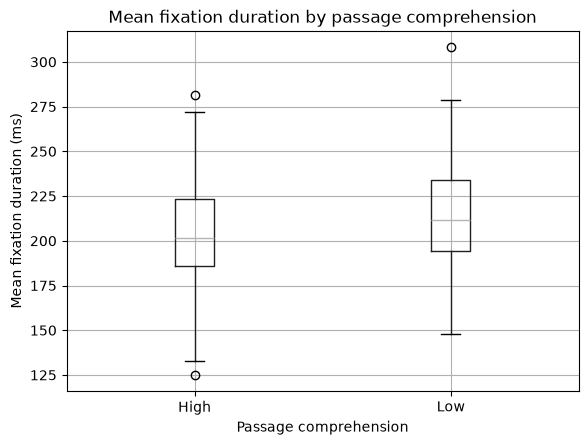

In [29]:
import matplotlib.pyplot as plt

analysis_complete.boxplot(
    column="mean_fix_duration",
    by="comprehension_level"
)

plt.xlabel("Passage comprehension")
plt.ylabel("Mean fixation duration (ms)")
plt.title("Mean fixation duration by passage comprehension")
plt.suptitle("")
plt.show()

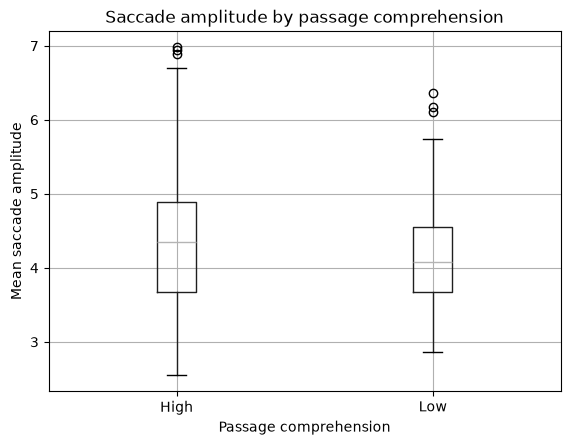

In [30]:
analysis_complete.boxplot(
    column="mean_saccade_amplitude",
    by="comprehension_level"
)

plt.xlabel("Passage comprehension")
plt.ylabel("Mean saccade amplitude")
plt.title("Saccade amplitude by passage comprehension")
plt.suptitle("")
plt.show()

## Initial descriptive results

The descriptive results show the same broad pattern as the original SB-SAT study:

* Low passage comprehension was associated with longer mean fixation durations
  (213.83 ms) than high comprehension (204.35 ms).
* Low passage comprehension showed smaller mean saccade amplitudes
  (4.16) than high comprehension (4.38).
* Participants also made more fixations on passages with low comprehension
  (721.67) than on passages with high comprehension (678.58).

However, the distributions show substantial overlap between the low- and
high-comprehension groups. These descriptive results therefore do not establish
whether the differences are statistically meaningful or whether they remain after
accounting for repeated observations from the same participants and differences
between passages.

In [31]:
predictors = [
    "mean_fix_duration",
    "median_fix_duration",
    "n_fixations",
    "mean_saccade_amplitude",
    "mean_pupil_size"
]

correlations = analysis_complete[predictors].corr()

print(correlations.round(2))

                        mean_fix_duration  median_fix_duration  n_fixations  \
mean_fix_duration                    1.00                 0.95         0.16   
median_fix_duration                  0.95                 1.00         0.13   
n_fixations                          0.16                 0.13         1.00   
mean_saccade_amplitude              -0.28                -0.23        -0.53   
mean_pupil_size                     -0.15                -0.20         0.01   

                        mean_saccade_amplitude  mean_pupil_size  
mean_fix_duration                        -0.28            -0.15  
median_fix_duration                      -0.23            -0.20  
n_fixations                              -0.53             0.01  
mean_saccade_amplitude                    1.00             0.17  
mean_pupil_size                           0.17             1.00  


### Why mixed-effects models?

Observations are not independent because each participant reads multiple
passages. Mixed-effects models are commonly used for repeated-measures data
in psycholinguistics and eye-tracking research because they can account for
variation between participants and items/texts.

In the current analysis:
* Participant is included as a random intercept.
* Passage is included as a fixed effect because there are only four passages.
* Eye-tracking measures are included as fixed-effect predictors.

The initial analyses use linear mixed-effects models for exploratory purposes.
However, passage comprehension is based on the number of correct answers out
of five questions (0–5), rather than a truly continuous outcome. Therefore, a
binomial generalized linear mixed-effects model (GLMM) would be preferable for
a final confirmatory analysis.

In [32]:
# Is mean fixation duration associated with passage comprehension, while accounting for repeated observations from the same participant and differences between passages?

# Standardizatoin: 0     = average fixation duration
# +1    = 1 SD longer than average
# -1    = 1 SD shorter than average

# C(book_name): systematic differences per passage
# groups=participant: participants have four observations, thus not independent

analysis_complete["z_fix_duration"] = (
    analysis_complete["mean_fix_duration"]
    - analysis_complete["mean_fix_duration"].mean()
) / analysis_complete["mean_fix_duration"].std()

import statsmodels.formula.api as smf

model_fix = smf.mixedlm(
    "comprehension_score ~ z_fix_duration + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_fix = model_fix.fit(reml=False)

print(result_fix.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0452             
Min. group size:   1        Log-Likelihood:      20.5411            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.580    0.025 23.439 0.000  0.532  0.629
C(book_name)[T.flytrap]   -0.028    0.032 -0.879 0.380 -0.091  0.035
C(book_name)[T.genome]    -0.070    0.032 -2.163 0.031 -0.134 -0.007
C(book_name)[T.northpole]  0.041    0.032  1.270 0.204 -0.022  0.104
z_fix_duration            -0.035    0.015 -2.390 0

C:\Users\Tim\AppData\Local\Temp\ipykernel_4280\1333485859.py:23: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result_fix = model_fix.fit(reml=False)


### Mixed-effects model: fixation duration

A linear mixed-effects model was used to examine whether mean fixation
duration was associated with passage comprehension. Participant was included
as a random intercept to account for repeated observations, and passage was
included as a fixed effect.

Mean fixation duration was standardized before analysis.

Longer mean fixation duration was significantly associated with lower
passage comprehension (β = -0.035, SE = 0.015, p = .017,
95% CI [-0.063, -0.006]).

Thus, a one-standard-deviation increase in mean fixation duration was
associated with an approximately 0.035 decrease in comprehension score,
after accounting for passage differences and repeated observations within
participants.

The model produced a boundary warning for the random-effect variance,
which should be considered when interpreting the model.

In [33]:
# Is greater mean saccade amplitude associated with passage comprehension, while accounting for repeated observations within participants and differences between passages?

# Standardize mean saccade amplitude
analysis_complete["z_saccade_amplitude"] = (
    analysis_complete["mean_saccade_amplitude"]
    - analysis_complete["mean_saccade_amplitude"].mean()
) / analysis_complete["mean_saccade_amplitude"].std()

# Mixed-effects model
model_saccade = smf.mixedlm(
    "comprehension_score ~ z_saccade_amplitude + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_saccade = model_saccade.fit(reml=False)

print(result_saccade.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0454             
Min. group size:   1        Log-Likelihood:      19.0192            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.586    0.025 23.718 0.000  0.538  0.634
C(book_name)[T.flytrap]   -0.037    0.032 -1.168 0.243 -0.100  0.025
C(book_name)[T.genome]    -0.079    0.032 -2.444 0.015 -0.142 -0.016
C(book_name)[T.northpole]  0.035    0.032  1.086 0.278 -0.028  0.098
z_saccade_amplitude        0.024    0.015  1.597 0

C:\Users\Tim\AppData\Local\Temp\ipykernel_4280\1504307507.py:16: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result_saccade = model_saccade.fit(reml=False)


### Mixed-effects model: saccade amplitude

A linear mixed-effects model was used to examine whether mean saccade
amplitude was associated with passage comprehension. Participant was included
as a random intercept to account for repeated observations, and passage was
included as a fixed effect.

Mean saccade amplitude was standardized before analysis.

Mean saccade amplitude showed a positive, but non-significant, association
with passage comprehension (β = 0.024, SE = 0.015, p = .110,
95% CI [-0.005, 0.053]).

Thus, larger saccade amplitudes tended to be associated with higher
comprehension, but there was insufficient statistical evidence for this
relationship after accounting for passage differences and repeated
observations within participants.

The direction of the association is consistent with the descriptive results
and with the original SB-SAT study, but the effect was not statistically
significant in the mixed-effects analysis.

In [34]:
# Are more fixations during a passage associated with lower passage comprehension, after accounting for passage differences and repeated observations within participants?

# Standardize fixation count
analysis_complete["z_fixation_count"] = (
    analysis_complete["n_fixations"]
    - analysis_complete["n_fixations"].mean()
) / analysis_complete["n_fixations"].std()

# Mixed-effects model
model_fix_count = smf.mixedlm(
    "comprehension_score ~ z_fixation_count + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_fix_count = model_fix_count.fit(reml=False)

print(result_fix_count.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0451             
Min. group size:   1        Log-Likelihood:      17.8678            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.586    0.025 23.098 0.000  0.536  0.635
C(book_name)[T.flytrap]   -0.032    0.034 -0.926 0.354 -0.098  0.035
C(book_name)[T.genome]    -0.078    0.033 -2.349 0.019 -0.143 -0.013
C(book_name)[T.northpole]  0.029    0.032  0.907 0.364 -0.033  0.091
z_fixation_count          -0.006    0.015 -0.407 0

### Mixed-effects model: fixation count

A linear mixed-effects model was used to examine whether fixation count was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Fixation count was standardized before analysis.

Fixation count was not significantly associated with passage comprehension
(β = -0.006, SE = 0.015, p = .684, 95% CI [-0.034, 0.023]).

Thus, the number of fixations made while reading a passage did not show a
meaningful relationship with passage comprehension after accounting for passage
differences and repeated observations within participants.

In [35]:
# Is mean pupil size associated with passage comprehension, after accounting for passage differences and repeated observations within participants?

# Standardize pupil size
analysis_complete["z_pupil_size"] = (
    analysis_complete["mean_pupil_size"]
    - analysis_complete["mean_pupil_size"].mean()
) / analysis_complete["mean_pupil_size"].std()

# Mixed-effects model
model_pupil = smf.mixedlm(
    "comprehension_score ~ z_pupil_size + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_pupil = model_pupil.fit(reml=False)

print(result_pupil.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0450             
Min. group size:   1        Log-Likelihood:      17.7854            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.588    0.025 23.626 0.000  0.539  0.636
C(book_name)[T.flytrap]   -0.036    0.032 -1.132 0.258 -0.099  0.026
C(book_name)[T.genome]    -0.081    0.032 -2.518 0.012 -0.144 -0.018
C(book_name)[T.northpole]  0.028    0.032  0.887 0.375 -0.034  0.090
z_pupil_size               0.000    0.015  0.018 0

### Mixed-effects model: pupil size

A linear mixed-effects model was used to examine whether mean pupil size was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Mean pupil size was standardized before analysis.

Mean pupil size was not associated with passage comprehension
(β = 0.000, SE = 0.015, p = .986, 95% CI [-0.030, 0.030]).

Thus, mean pupil size did not provide evidence of a relationship with passage
comprehension after accounting for passage differences and repeated observations
within participants.

This is consistent with the original SB-SAT study, which also did not find
significant differences in pupil size between comprehension groups.

In [36]:
# Is regression rate associated with passage comprehension,
# after accounting for passage differences and repeated observations within participants?

# Keep fixations that landed on a defined word/interest area
reading_words = reading.dropna(
    subset=["CURRENT_FIX_INTEREST_AREA_ID"]
).copy()

# Previous word/interest area within the same participant, passage, and page
reading_words["previous_ia_id"] = (
    reading_words
    .groupby([
        "RECORDING_SESSION_LABEL",
        "book_name",
        "page"
    ])["CURRENT_FIX_INTEREST_AREA_ID"]
    .shift(1)
)

# A regression occurs when gaze moves back to an earlier interest area
reading_words["is_regression"] = (
    reading_words["CURRENT_FIX_INTEREST_AREA_ID"]
    < reading_words["previous_ia_id"]
)

# Calculate regression features per participant × passage
regression_features = (
    reading_words
    .dropna(subset=["previous_ia_id"])
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_regressions=("is_regression", "sum"),
        n_transitions=("is_regression", "count")
    )
    .reset_index()
)

# Proportion of word-to-word transitions that are regressions
regression_features["regression_rate"] = (
    regression_features["n_regressions"]
    / regression_features["n_transitions"]
)

print(regression_features.head())

  RECORDING_SESSION_LABEL  book_name  n_regressions  n_transitions  \
0                  msd001    dickens             94            491   
1                  msd001    flytrap            139            632   
2                  msd001     genome             72            488   
3                  msd001  northpole             65            366   
4                  msd002    dickens             98            632   

   regression_rate  
0         0.191446  
1         0.219937  
2         0.147541  
3         0.177596  
4         0.155063  


In [37]:
analysis_complete = analysis_complete.merge(
    regression_features,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

print(
    analysis_complete[
        ["n_regressions", "n_transitions", "regression_rate"]
    ].describe()
)

       n_regressions  n_transitions  regression_rate
count     357.000000     357.000000       357.000000
mean      137.081232     657.563025         0.208501
std        55.037134     182.291946         0.056074
min        14.000000      49.000000         0.039720
25%        97.000000     527.000000         0.173112
50%       130.000000     645.000000         0.206349
75%       167.000000     789.000000         0.244074
max       390.000000    1139.000000         0.403712


In [38]:
# Standardize regression rate
analysis_complete["z_regression_rate"] = (
    analysis_complete["regression_rate"]
    - analysis_complete["regression_rate"].mean()
) / analysis_complete["regression_rate"].std()

# Mixed-effects model
model_regression = smf.mixedlm(
    "comprehension_score ~ z_regression_rate + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_regression = model_regression.fit(reml=False)

print(result_regression.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0449             
Min. group size:   1        Log-Likelihood:      18.4451            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.584    0.025 23.407 0.000  0.535  0.633
C(book_name)[T.flytrap]   -0.032    0.032 -0.987 0.323 -0.095  0.031
C(book_name)[T.genome]    -0.076    0.032 -2.346 0.019 -0.139 -0.012
C(book_name)[T.northpole]  0.032    0.032  1.007 0.314 -0.030  0.094
z_regression_rate          0.017    0.015  1.150 0

### Mixed-effects model: regression rate

A linear mixed-effects model was used to examine whether regression rate was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Regression rate was standardized before analysis.

Regression rate was not significantly associated with passage comprehension
(β = 0.017, SE = 0.015, p = .250, 95% CI [-0.012, 0.046]).

The coefficient was positive, suggesting that a higher regression rate tended
to be associated with slightly higher comprehension, but there was insufficient
statistical evidence for this relationship after accounting for passage
differences and repeated observations within participants.

### Follow-up analysis: binomial generalized linear mixed-effects model

The initial analyses used linear mixed-effects models with passage comprehension
score (0.0–1.0) as the outcome.

However, passage comprehension is based on the number of correct answers to
five comprehension questions. The possible scores are therefore discrete
(0, 0.2, 0.4, 0.6, 0.8, and 1.0), rather than truly continuous.

A binomial generalized linear mixed-effects model (GLMM) is therefore more
appropriate for a confirmatory analysis because it models whether individual
comprehension questions were answered correctly or incorrectly.

The first GLMM focuses on mean fixation duration because this was the only
eye-tracking measure that showed a statistically significant association with
comprehension in the exploratory linear mixed-effects models.

The model examines whether mean fixation duration predicts the probability of
answering a comprehension question correctly while:
* accounting for repeated observations from the same participant using a
  participant random intercept;
* controlling for systematic differences between passages using passage as a
  fixed effect.

The aim is to examine whether the negative relationship between fixation
duration and comprehension remains when the outcome is modelled using a
binomial distribution.

In [40]:
# Keep fixation duration for the complete participant × passage observations
fixation_for_glmm = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration"
    ]
].copy()

# Merge passage-level fixation duration with individual comprehension questions
glmm_df = comprehension_questions.merge(
    fixation_for_glmm,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_df.head(10))
print(glmm_df.shape)
print(glmm_df["correct"].value_counts())

  RECORDING_SESSION_LABEL book_name  page  answer  correct_answer  correct  \
0                  msd001   dickens     1       1               1        1   
1                  msd001   dickens     2       3               3        1   
2                  msd001   dickens     3       3               1        0   
3                  msd001   dickens     4       4               4        1   
4                  msd001   dickens     5       2               3        0   
5                  msd001   flytrap     1       1               1        1   
6                  msd001   flytrap     2       3               3        1   
7                  msd001   flytrap     3       4               4        1   
8                  msd001   flytrap     4       2               2        1   
9                  msd001   flytrap     5       4               2        0   

   z_fix_duration  
0       -0.874583  
1       -0.874583  
2       -0.874583  
3       -0.874583  
4       -0.874583  
5       -0.311707  
6

In [41]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# Is mean fixation duration associated with the probability of answering
# a comprehension question correctly?

model_glmm_fix = BinomialBayesMixedGLM.from_formula(
    "correct ~ z_fix_duration + C(book_name)",
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_df
)

result_glmm_fix = model_glmm_fix.fit_vb()

print(result_glmm_fix.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3395   0.0487                      
C(book_name)[T.flytrap]      M    -0.1189   0.0969                      
C(book_name)[T.genome]       M    -0.2952   0.0975                      
C(book_name)[T.northpole]    M     0.1772   0.0973                      
z_fix_duration               M    -0.1479   0.0490                      
participant                  V    -0.9177   0.0727 0.399   0.345   0.462
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Binomial GLMM: fixation duration

Because passage comprehension is based on five individual comprehension
questions, a binomial mixed-effects model was used as a follow-up analysis.

Correct/incorrect responses to individual comprehension questions were used
as the outcome. Mean fixation duration was measured at the participant × passage
level and standardized before analysis.

Participant was included as a random intercept to account for repeated
observations, and passage was included as a fixed effect.

Mean fixation duration showed a negative association with the probability of
answering a comprehension question correctly
(posterior mean = -0.148, posterior SD = 0.049).

Thus, longer mean fixation durations were associated with a lower probability
of answering comprehension questions correctly.

This result is consistent with the earlier linear mixed-effects model:

* **LMM:** longer fixation duration was associated with lower passage
  comprehension (β = -0.035, p = .017).
* **Binomial GLMM:** longer fixation duration was associated with a lower
  probability of answering an individual comprehension question correctly
  (posterior mean = -0.148, posterior SD = 0.049).

The consistency between the two analyses strengthens the evidence that mean
fixation duration is related to comprehension.

#### Participant differences

The estimated standard deviation of the participant random intercept was
approximately 0.399. This indicates variation between participants in their
general probability of answering comprehension questions correctly, supporting
the inclusion of participant as a random effect.

#### Passage differences

Dickens was the reference passage. Relative to Dickens, the estimated passage
effects were:

* Flytrap: -0.119
* Genome: -0.295
* Northpole: 0.177

Genome showed the strongest negative estimated difference relative to Dickens.
These passage effects are included primarily to control for systematic
differences between texts rather than being the main focus of the analysis.

### Next analysis: multivariable GLMM

The previous analyses examined each eye-tracking measure separately.

The next step is to examine whether mean fixation duration remains associated
with comprehension when other characteristics of reading behaviour are included
in the same model.

A multivariable binomial GLMM will include:

* mean fixation duration;
* mean saccade amplitude;
* regression rate;
* passage as a fixed effect;
* participant as a random intercept.

This allows examination of the independent association of each eye-tracking
measure with the probability of answering a comprehension question correctly.

Mean and median fixation duration will not both be included because they are
very highly correlated (r = .95). Pupil size and fixation count are initially
excluded because the previous single-predictor analyses showed little evidence
of an association with comprehension.

In [42]:
# Standardize additional predictors at participant × passage level
analysis_complete["z_saccade_amplitude"] = (
    analysis_complete["mean_saccade_amplitude"]
    - analysis_complete["mean_saccade_amplitude"].mean()
) / analysis_complete["mean_saccade_amplitude"].std()

analysis_complete["z_regression_rate"] = (
    analysis_complete["regression_rate"]
    - analysis_complete["regression_rate"].mean()
) / analysis_complete["regression_rate"].std()

In [43]:
predictors_for_glmm = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration",
        "z_saccade_amplitude",
        "z_regression_rate"
    ]
].copy()

glmm_multi_df = comprehension_questions.merge(
    predictors_for_glmm,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_multi_df.head())
print(glmm_multi_df.shape)

  RECORDING_SESSION_LABEL book_name  page  answer  correct_answer  correct  \
0                  msd001   dickens     1       1               1        1   
1                  msd001   dickens     2       3               3        1   
2                  msd001   dickens     3       3               1        0   
3                  msd001   dickens     4       4               4        1   
4                  msd001   dickens     5       2               3        0   

   z_fix_duration  z_saccade_amplitude  z_regression_rate  
0       -0.874583             1.278931           -0.30416  
1       -0.874583             1.278931           -0.30416  
2       -0.874583             1.278931           -0.30416  
3       -0.874583             1.278931           -0.30416  
4       -0.874583             1.278931           -0.30416  
(1785, 9)


from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

model_glmm_multi = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_fix_duration +
        z_saccade_amplitude +
        z_regression_rate +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_multi_df
)

result_glmm_multi = model_glmm_multi.fit_vb()

print(result_glmm_multi.summary())

### Multivariable binomial GLMM

A multivariable binomial mixed-effects model was used to examine whether
mean fixation duration remained associated with comprehension when other
eye-tracking characteristics were considered simultaneously.

The model included:
* mean fixation duration;
* mean saccade amplitude;
* regression rate;
* passage as a fixed effect;
* participant as a random intercept.

All eye-tracking predictors were standardized before analysis.

Mean fixation duration remained negatively associated with the probability
of answering a comprehension question correctly
(posterior mean = -0.127, posterior SD = 0.049).

The approximate 95% posterior interval for fixation duration was
[-0.223, -0.031], remaining below zero.

On the odds scale, this corresponds to an odds ratio of approximately 0.88.
Thus, a one-standard-deviation increase in mean fixation duration was
associated with approximately 12% lower odds of answering a comprehension
question correctly, while holding the other predictors and passage constant.

Mean saccade amplitude showed a positive estimate
(posterior mean = 0.061, posterior SD = 0.050), but its approximate 95%
posterior interval included zero.

Regression rate also showed little evidence of an independent association
with comprehension
(posterior mean = 0.026, posterior SD = 0.049).

Overall, mean fixation duration was the only included eye-tracking measure
that showed a clear independent relationship with comprehension in this model.

Is comprehension related to the fact that some students generally have longer fixations than others, or is it related to a student having longer fixations than usual for that particular student on a passage?

In [47]:
# Participant's average fixation duration across passages
analysis_complete["person_mean_fix_duration"] = (
    analysis_complete
    .groupby("RECORDING_SESSION_LABEL")["mean_fix_duration"]
    .transform("mean")
)

# Deviation from that participant's own average
analysis_complete["within_fix_duration"] = (
    analysis_complete["mean_fix_duration"]
    - analysis_complete["person_mean_fix_duration"]
)

In [48]:
analysis_complete["z_between_fix_duration"] = (
    analysis_complete["person_mean_fix_duration"]
    - analysis_complete["person_mean_fix_duration"].mean()
) / analysis_complete["person_mean_fix_duration"].std()

analysis_complete["z_within_fix_duration"] = (
    analysis_complete["within_fix_duration"]
    - analysis_complete["within_fix_duration"].mean()
) / analysis_complete["within_fix_duration"].std()

In [49]:
within_between_predictors = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_between_fix_duration",
        "z_within_fix_duration"
    ]
].copy()

glmm_within_between = comprehension_questions.merge(
    within_between_predictors,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

In [50]:
model_within_between = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_between_fix_duration +
        z_within_fix_duration +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_within_between
)

result_within_between = model_within_between.fit_vb()

print(result_within_between.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3759   0.0488                      
C(book_name)[T.flytrap]      M    -0.1537   0.0970                      
C(book_name)[T.genome]       M    -0.3457   0.0975                      
C(book_name)[T.northpole]    M     0.1197   0.0974                      
z_between_fix_duration       M    -0.1619   0.0489                      
z_within_fix_duration        M     0.0043   0.0493                      
participant                  V    -0.9185   0.0727 0.399   0.345   0.462
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Within-person versus between-person fixation duration

To examine whether the fixation-duration effect reflects differences between
students or changes within the same student across passages, mean fixation
duration was decomposed into:

* **Between-person fixation duration:** a participant's average fixation
  duration across passages.
* **Within-person fixation duration:** the deviation in fixation duration for
  a particular passage from that participant's own average.

A binomial mixed-effects model included both components, passage as a fixed
effect, and participant as a random intercept.

The between-person fixation-duration effect was clearly negative
(posterior mean = -0.162, posterior SD = 0.049; approximate 95% posterior
interval [-0.258, -0.066]).

This corresponds to an odds ratio of approximately 0.85: participants whose
average fixation duration was one standard deviation higher had approximately
15% lower odds of answering a comprehension question correctly.

In contrast, the within-person fixation-duration effect was close to zero
(posterior mean = 0.004, posterior SD = 0.049; approximate 95% posterior
interval [-0.092, 0.101]).

Thus, the previously observed relationship between longer fixation durations
and lower comprehension appears to be primarily a **between-reader effect**.
There was no clear evidence that a student having longer fixations than usual
on a particular passage was associated with lower comprehension on that
passage.

This distinction is relevant for interpreting eye-tracking analytics:
fixation duration may reflect relatively stable differences between readers
more strongly than passage-specific comprehension difficulty.

In [51]:
# Sensitivity analysis:
# Remove the unusually sparse msd012 × dickens recording

analysis_sensitivity = analysis_complete[
    ~(
        (analysis_complete["RECORDING_SESSION_LABEL"] == "msd012") &
        (analysis_complete["book_name"] == "dickens")
    )
].copy()

print(analysis_complete.shape)
print(analysis_sensitivity.shape)

(357, 26)
(356, 26)


In [52]:
predictors_sensitivity = analysis_sensitivity[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration",
        "z_saccade_amplitude",
        "z_regression_rate"
    ]
].copy()

glmm_sensitivity_df = comprehension_questions.merge(
    predictors_sensitivity,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_sensitivity_df.shape)

(1780, 9)


In [53]:
model_glmm_sensitivity = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_fix_duration +
        z_saccade_amplitude +
        z_regression_rate +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_sensitivity_df
)

result_glmm_sensitivity = model_glmm_sensitivity.fit_vb()

print(result_glmm_sensitivity.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3414   0.0488                      
C(book_name)[T.flytrap]      M    -0.1268   0.0970                      
C(book_name)[T.genome]       M    -0.2945   0.0976                      
C(book_name)[T.northpole]    M     0.1884   0.0974                      
z_fix_duration               M    -0.1309   0.0493                      
z_saccade_amplitude          M     0.0631   0.0498                      
z_regression_rate            M     0.0269   0.0491                      
participant                  V    -0.9333   0.0727 0.393   0.340   0.455
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Sensitivity analysis

One participant–passage observation (`msd012 × Dickens`) contained all five
pages but only 56 recorded fixations, making it an unusually sparse eye-tracking
recording.

To examine whether this observation influenced the main findings, the
multivariable binomial GLMM was repeated after excluding this observation.

The results were virtually unchanged:

* Mean fixation duration:
  * Original model: posterior mean = -0.127
  * Sensitivity model: posterior mean = -0.131, posterior SD = 0.049
* Mean saccade amplitude:
  * Original model: 0.061
  * Sensitivity model: 0.063
* Regression rate:
  * Original model: 0.026
  * Sensitivity model: 0.027

The approximate 95% posterior interval for mean fixation duration remained
below zero [-0.228, -0.034].

Thus, the negative relationship between mean fixation duration and
comprehension was not driven by the unusually sparse recording and appears
robust to its exclusion.